In this Notebook we are aiming to find clusters of accidents events causing personal injury in Frankfurt am Main. 

As a first step we are loading in all packages and our preprocessed data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

import fetch_data as fd
import plotting as pl
from clusters import analyze_clusters
from fetch_data import fetch_traffic_data
from fetch_data import get_city_info
fetch_traffic_data()
get_city_info()

Already have 2016.csv, skipping...
Already have 2017.csv, skipping...
Already have 2018.csv, skipping...
Already have 2019.csv, skipping...
Already have 2020.csv, skipping...
Already have 2021.csv, skipping...
Already have 2022.csv, skipping...
Already have 2023.csv, skipping...
Already have 2024.csv, skipping...


,regional key,city,sq km,population
0,11000000,Berlin,891.12,3685265
1,02000000,Hamburg,755.09,1862565
2,09162000,München,310.70,1505005
3,05315000,Köln,405.02,1024621
4,06412000,Frankfurt am Main,248.31,756021
...,...,...,...,...
2054,16075127,Ziegenrück,8.25,626
2055,16071061,Neumark,8.67,462
2056,16069052,Ummerstadt,15.73,455
2057,03354021,Schnackenburg,23.70,447


In [2]:
YEARS = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
df_dict = fd.get_dfs(YEARS)
df = pd.concat(df_dict.values())
city_info = fd.get_city_info()

# Create Frankfurt specific Dataframe
Frankfurt = df[df["Community_key"] == "06412000"]
Frankfurt.shape
Frankfurt.groupby("UKATEGORIE").size()

# Rename vlaues in UTYP for easier analysis
accident_map = {
    1: "Driving accident",
    2: "Accident caused by turning off the road",
    3: "Accident caused by turning into a road or by crossing it",
    4: "Accident caused by crossing the road",
    5: "Accident involving stationary",
    6: "Accident between vehicles moving along in carriageway",
    7: "Other accident"
}

Frankfurt.loc[:, 'UTYP1'] = Frankfurt['UTYP1'].map(accident_map)
Frankfurt.head()

/var/folders/vc/0j4mdmf57czgyfw41r8jjvxm0000gn/T/ipykernel_40825/1605333988.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Driving accident'
 'Accident between vehicles moving along in carriageway'
 'Accident caused by turning into a road or by crossing it' ...
 'Accident between vehicles moving along in carriageway'
 'Accident caused by turning into a road or by crossing it'
 'Accident between vehicles moving along in carriageway']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Frankfurt.loc[:, 'UTYP1'] = Frankfurt['UTYP1'].map(accident_map)


,OID_,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,...,IstFuss,IstKrad,IstGkfz,IstSonstige,LINREFX,LINREFY,XGCSWGS84,YGCSWGS84,Community_key,UID
8575,8576,06,4,12,000,2016,1,19,7,3,...,0,0,0.0,0,471854.4512,5.545148e+06,8.606800,50.057949,06412000,2016_8576
8664,8665,06,4,12,000,2016,1,0,1,3,...,0,0,0.0,0,465949.1018,5.551119e+06,8.523772,50.111344,06412000,2016_8665
8978,8979,06,4,12,000,2016,1,15,7,1,...,0,0,0.0,0,467209.1346,5.550947e+06,8.541409,50.109870,06412000,2016_8979
9024,9025,06,4,12,000,2016,1,2,1,2,...,0,0,0.0,0,475327.1534,5.547310e+06,8.655174,50.077547,06412000,2016_9025
9074,9075,06,4,12,000,2016,1,3,6,3,...,0,0,0.0,0,477911.2036,5.548912e+06,8.691196,50.092058,06412000,2016_9075


As a first step we will try to get a rough Overview about the distribution of accidents events across the city. 
We can see that the accident spread across the entire city, with the highest concentration of accidents being close to it's center.
This is about what one would expect, so to get actual insights we need to dig deeper.

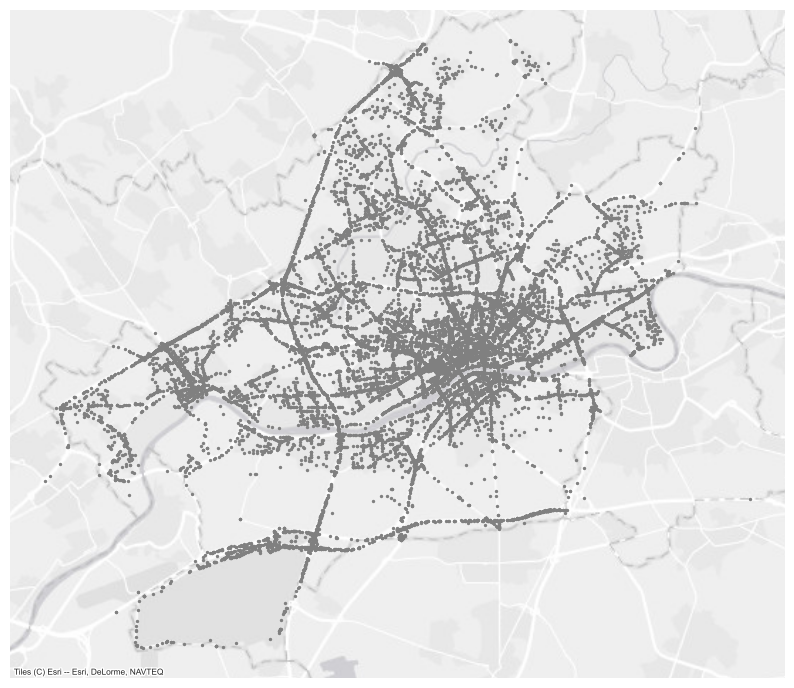

In [3]:
fig, ax = plt.subplots(figsize=(10, 10))
pl.point_map(Frankfurt, size=2, alpha=1, ax=ax)
plt.show()

As the next step, we are checking accident distribution across the city by creating weighted center points. For our Accident data, we calculate the mean location of accidents, and then compare those against the Geographical and Physical Center of Frankufrt. From the results we can see that the Mean accident Centers with Bicycle, Pedestrian, and Car involvement are closer to the Frankfurt city center then the Geographical Center points. Since that in itself is not to insightful either, we will need to deploy a clustering alogorithm to get some deeper insights.

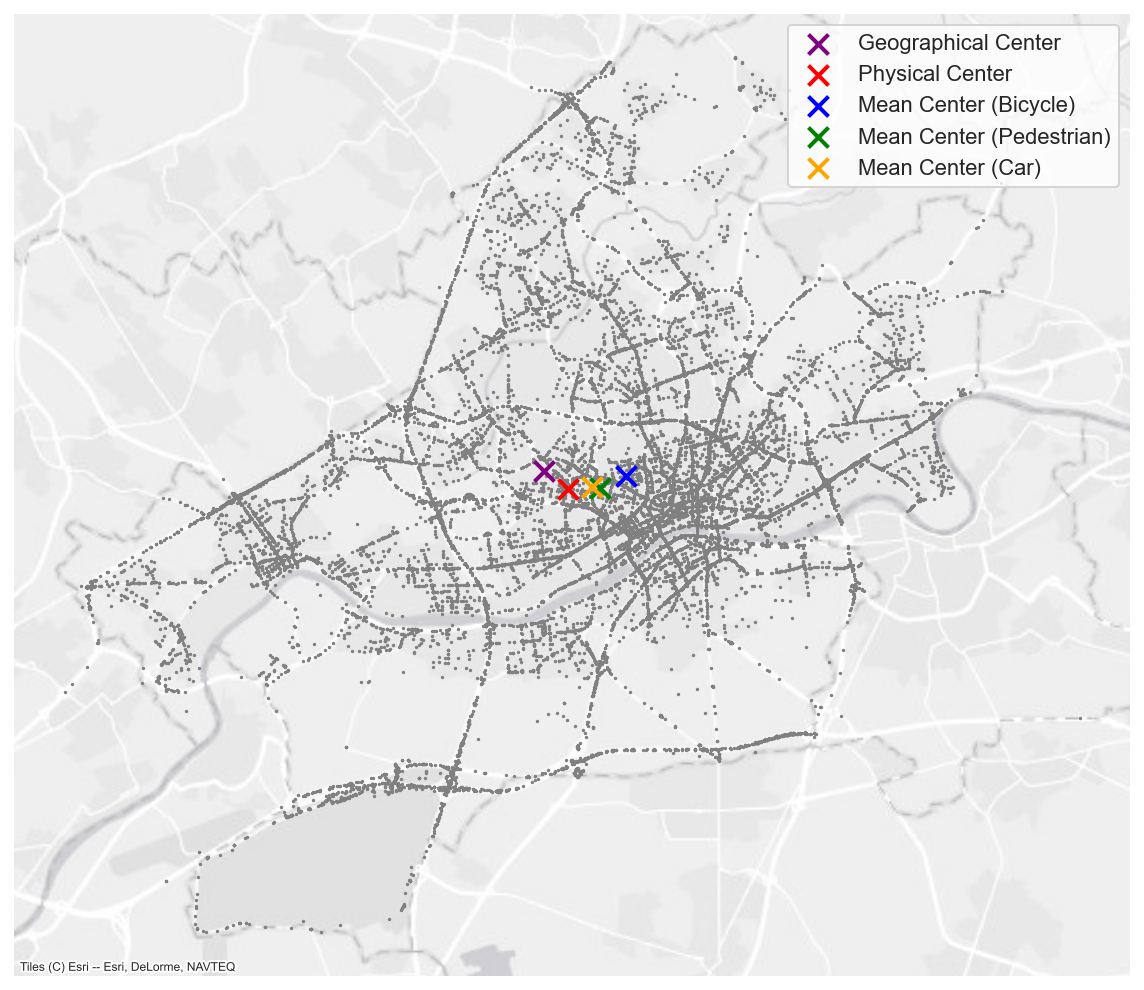

In [4]:
# (lat, lon, color, label)
centers = [
    (50.121250, 8.636583, "purple", "Geographical Center"),
    (50.117306, 8.644417, "red", "Physical Center"),
]
# Mean center per participant type
for col, color, label in [
    ("IstRad", "blue", "Bicycle"),
    ("IstFuss", "green", "Pedestrian"),
    ("IstPKW", "orange", "Car"),
]:
    sub = Frankfurt[Frankfurt[col] == 1]
    centers.append((sub["YGCSWGS84"].mean(), sub["XGCSWGS84"].mean(), color, f"Mean Center ({label})"))

fig, ax = plt.subplots(figsize=(10, 10), dpi=144)
pl.point_map(Frankfurt, size=0.5, alpha=1, centers=centers, ax=ax)
plt.show()

# DBSCAN 
For this analysis, we are choosing to use the DBSCAN (Density-Based Spatial Clustering of Applications with Noise) algorithm.
There are many potential Clustering algorithms that could be used on this dataset, but we chose DBSCAN specifically due to its favorable attributes for our analysis:
1. DBSCAN is a density-based algorithm, meaning it's specifically designed to find regions where points are packed closely together, which lines up with our goal
2. Accident hotspots comes in all kinds of shapes. A hotspot might follow a winding section of a highway, or form a "T" shape at a dangerous intersection. DBSCAN does not assume any        shapes, which lines up with our use-case.
3. For our analysis, we want to find systemic hotspots, and want to seperate them from random incidents. As DBSCAN allows for noise, it will exclude isolated points from our clusters rather then associate them with a cluster


To get started, we need to choose our input for the two main parameters that can be tuned with DBSCAN: Eps (ε) and and the minimum samples.
Since we have no good knowledge about which numbers could be appropriate, and one way of getting a good estimate is to use an Elbow curve with the sklearn NearestNeighbors alogirthm.

When we choose k = 20 as a starting point, and get the below curve. The result shows us that we can expect get a good clustering result if we choose ε to be between 350-400.
In our case though, we will use a slightly different approach. We assume that two accident events are related if they are within 100 meters of each other. Since we are only looking for the most dense areas, we will set eps = 100 and then scale our minimum samples until 5 or less clusters remain which then get analyzed based on the causes for the accidents.


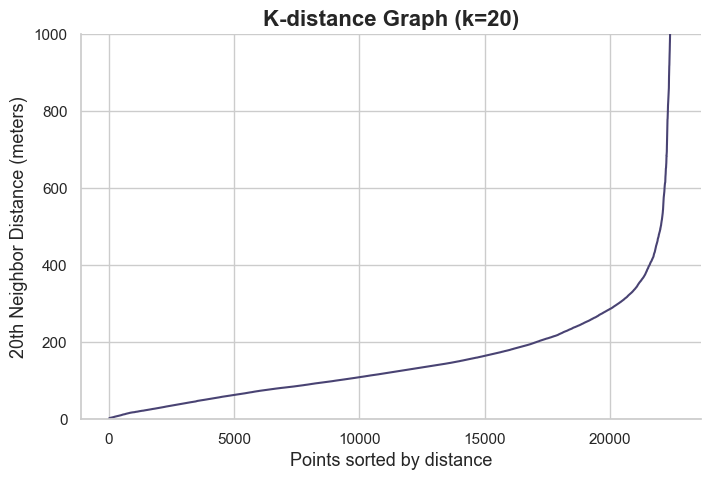

In [5]:
data_for_clustering = Frankfurt[["LINREFX", "LINREFY"]]

k = 20
distances, _ = NearestNeighbors(n_neighbors=k).fit(data_for_clustering).kneighbors(data_for_clustering)

fig, ax = plt.subplots(figsize=(8, 5))
pl.knn_distance(distances[:, k - 1], k, f"K-distance Graph (k={k})", ax=ax)
ax.set_ylabel(f"{k}th Neighbor Distance (meters)")
ax.set_ylim(0, 1000)
plt.show()

First, we are plotting all accident events and see where the main hotspots for accidents of any kind are in Frankfurt. 
We achieve 5 or less clusters for a min samples value of 85, ε is fixed to 100. The result is the below cluster.
We examine Cluster 2 specifically due to it's proximity to our Frankfurt School of Finance and Management.

Found 4 clusters.
Cluster Center Coordinates
         Latitude  Longitude  \
labels                         
0       50.118726   8.731378   
1       50.148025   8.666328   
2       50.131795   8.683852   
3       50.107326   8.656040   

                                                                           Google_Maps_Link  
labels                                                                                       
0        https://www.google.com/maps/search/?api=1&query=50.11872602334982,8.73137784321529  
1       https://www.google.com/maps/search/?api=1&query=50.14802549700004,8.666327938444482  
2       https://www.google.com/maps/search/?api=1&query=50.13179462461391,8.683851999604004  
3       https://www.google.com/maps/search/?api=1&query=50.10732622077533,8.656040092415775  


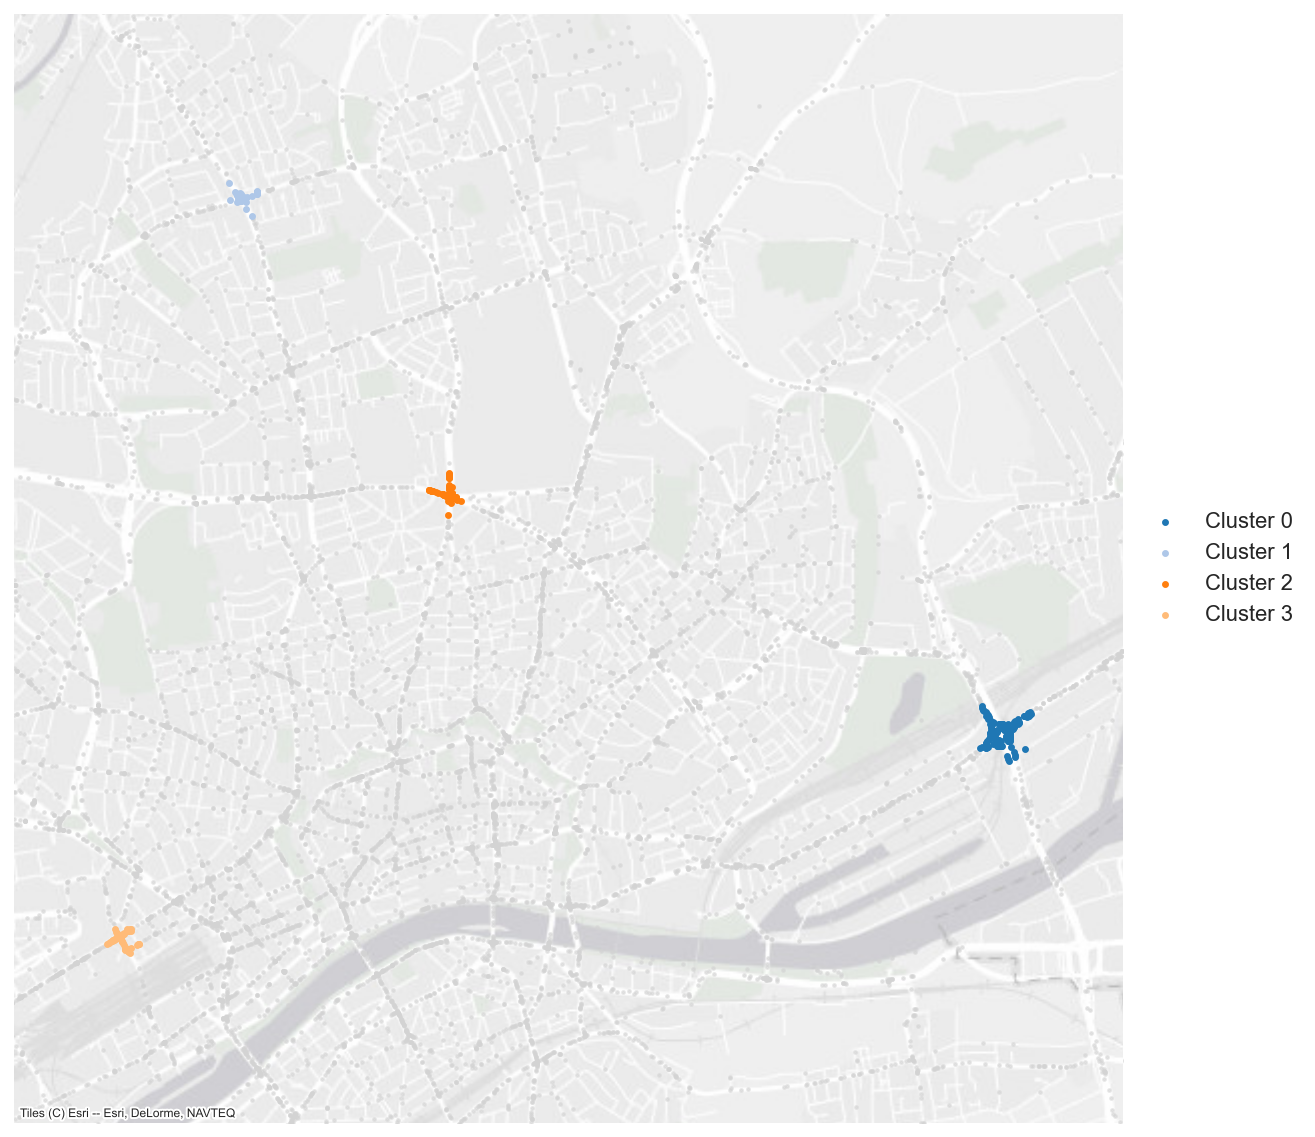

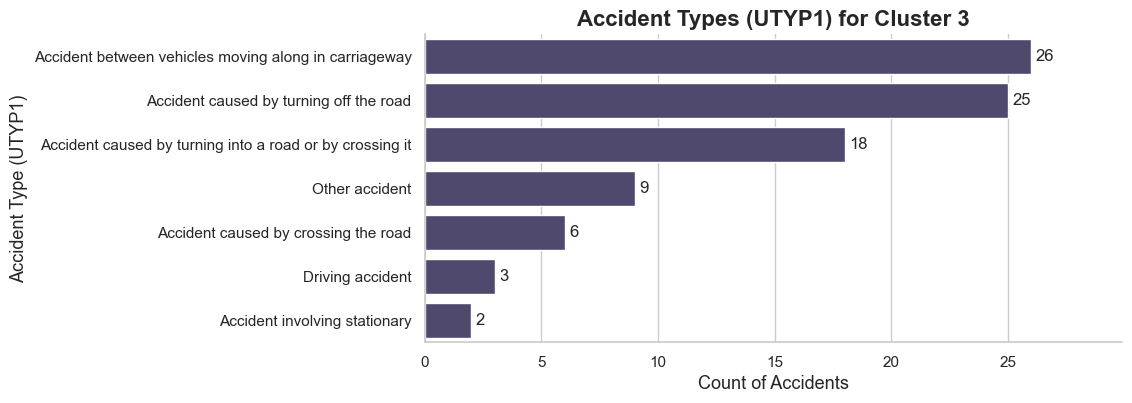

,OID_,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,...,IstKrad,IstGkfz,IstSonstige,LINREFX,LINREFY,XGCSWGS84,YGCSWGS84,Community_key,UID,labels
10553,10554,06,4,12,000,2016,1,18,1,3,...,0,0.0,0,480839.4262,5.551839e+06,8.731985,50.118487,06412000,2016_10554,0
10638,10639,06,4,12,000,2016,2,15,6,3,...,0,0.0,1,476159.5300,5.555149e+06,8.666318,50.148082,06412000,2016_10639,1
10710,10711,06,4,12,000,2016,2,14,5,3,...,0,1.0,0,480805.6656,5.551889e+06,8.731510,50.118938,06412000,2016_10711,0
10873,10874,06,4,12,000,2016,2,8,3,3,...,0,0.0,0,480869.4288,5.551723e+06,8.732411,50.117445,06412000,2016_10874,0
10887,10888,06,4,12,000,2016,2,17,2,3,...,0,0.0,1,476144.5992,5.555134e+06,8.666110,50.147946,06412000,2016_10888,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194808,194809,06,4,12,000,2024,8,18,3,3,...,0,0.0,0,475417.8726,5.550558e+06,8.656233,50.106765,06412000,2024_194809,3
195323,195324,06,4,12,000,2024,8,16,5,2,...,1,0.0,0,475360.5070,5.550686e+06,8.655423,50.107915,06412000,2024_195324,3
195431,195432,06,4,12,000,2024,11,20,3,3,...,0,0.0,0,477436.0840,5.553314e+06,8.684293,50.131630,06412000,2024_195432,2
195585,195586,06,4,12,000,2024,11,7,5,3,...,0,0.0,0,475398.8646,5.550615e+06,8.655964,50.107279,06412000,2024_195586,3


In [6]:
# All Accident events
analyze_clusters(Frankfurt, eps=100, min_samples=85, cluster_to_plot=3)

In the next step, we are filtering the dataset to accidents that include bicycles. This does not exclude Pedestrians or Cars from the accidents, but makes sure every accident involves a cyclist. We keep ε fixed to 100, and achieve 5 Clusters for minimum samples = 40.

We are fetching the reasons for accidents in Cluster 3 due to its location next to the river.
We can see that the vast majority of accidents are caused by turning off the road, which means that cyclists are likely hit by cars when they leave the street for another direction.
The location can be inspected through the provided google maps link.

Found 5 clusters.
Cluster Center Coordinates
         Latitude  Longitude  \
labels                         
0       50.131888   8.683750   
1       50.132667   8.695200   
2       50.109310   8.694488   
3       50.107707   8.675633   
4       50.114837   8.670445   

                                                                            Google_Maps_Link  
labels                                                                                        
0       https://www.google.com/maps/search/?api=1&query=50.131887668760044,8.683750031440045  
1        https://www.google.com/maps/search/?api=1&query=50.13266749806784,8.695199520271231  
2        https://www.google.com/maps/search/?api=1&query=50.10931003965222,8.694488326195692  
3        https://www.google.com/maps/search/?api=1&query=50.10770682661707,8.675633276106428  
4       https://www.google.com/maps/search/?api=1&query=50.114836522707364,8.670444865634185  


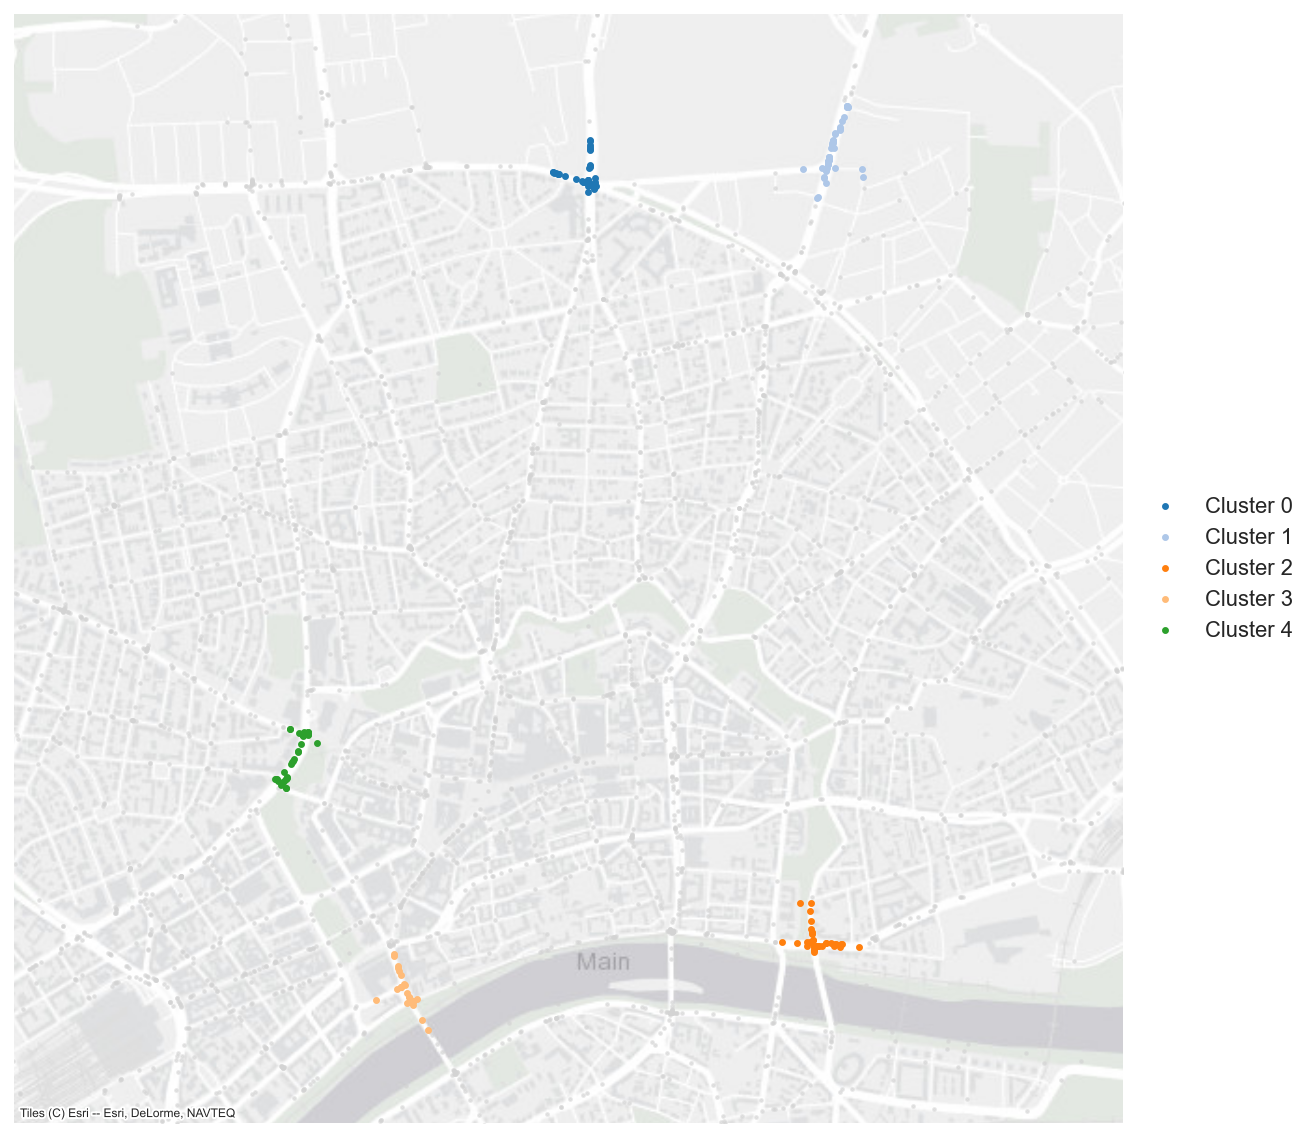

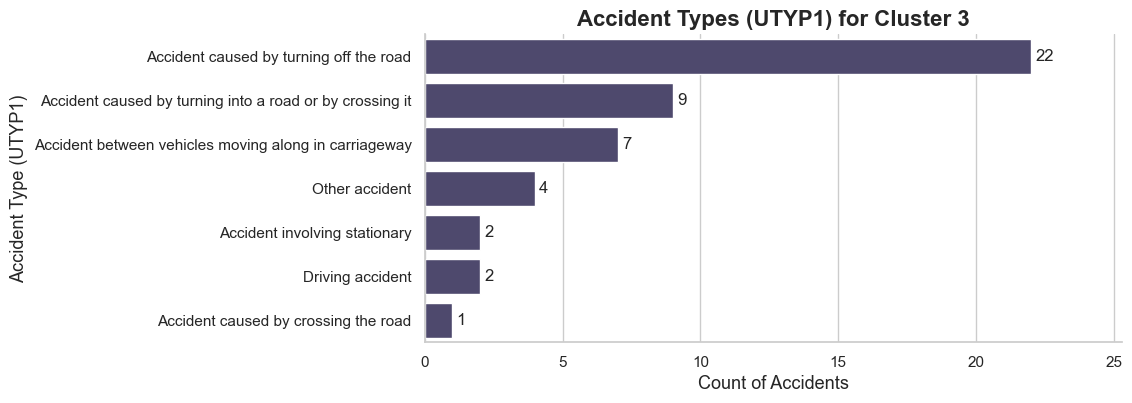

,OID_,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,...,IstKrad,IstGkfz,IstSonstige,LINREFX,LINREFY,XGCSWGS84,YGCSWGS84,Community_key,UID,labels
11630,11631,06,4,12,000,2016,3,8,6,3,...,0,0.0,1,477414.85910,5.553372e+06,8.683993,50.132156,06412000,2016_11631,0
12686,12687,06,4,12,000,2016,4,2,7,3,...,0,0.0,0,478036.79720,5.550825e+06,8.692841,50.109268,06412000,2016_12687,2
13109,13110,06,4,12,000,2016,4,14,6,3,...,0,0.0,0,478251.02950,5.553532e+06,8.695683,50.133626,06412000,2016_13110,1
13636,13637,06,4,12,000,2016,4,12,6,3,...,0,0.0,0,477400.55410,5.553321e+06,8.683796,50.131693,06412000,2016_13637,0
14921,14922,06,4,12,000,2016,6,12,2,2,...,0,0.0,1,478211.20070,5.553434e+06,8.695131,50.132743,06412000,2016_14922,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194933,194934,06,4,12,000,2024,9,7,3,3,...,0,0.0,0,476783.03790,5.550683e+06,8.675316,50.107947,06412000,2024_194934,3
195249,195250,06,4,12,000,2024,8,8,2,3,...,0,0.0,1,476777.80880,5.550737e+06,8.675240,50.108430,06412000,2024_195250,3
196233,196234,06,4,12,000,2024,10,0,1,3,...,0,0.0,1,476423.35930,5.551417e+06,8.670241,50.114529,06412000,2024_196234,4
264341,264342,06,4,12,000,2024,7,17,4,3,...,0,0.0,1,476510.91000,5.551484e+06,8.671462,50.115137,06412000,2024_264342,4


In [7]:
# Bicycle Clusters
analyze_clusters(Frankfurt[Frankfurt["IstRad"] == 1], eps=100, min_samples=40, cluster_to_plot=3)

In the next step, we are filtering the dataset to accidents that include pedestrians. We keep ε fixed to 100, and achieve 5 Clusters for minimum samples = 20. the low amount of minimum samples is needed due to the prevelance of pedestrians is rather low.

We are fetching the reasons for accidents in Cluster 1, as its location seems unintuative.

Found 5 clusters.
Cluster Center Coordinates
         Latitude  Longitude  \
labels                         
0       50.107623   8.665251   
1       50.127003   8.692066   
2       50.114260   8.687714   
3       50.109289   8.665735   
4       50.123177   8.701829   

                                                                            Google_Maps_Link  
labels                                                                                        
0        https://www.google.com/maps/search/?api=1&query=50.10762310240005,8.665250677780044  
1         https://www.google.com/maps/search/?api=1&query=50.12700253795459,8.69206562454549  
2       https://www.google.com/maps/search/?api=1&query=50.114259839911156,8.687714124533379  
3        https://www.google.com/maps/search/?api=1&query=50.10928948112505,8.665734736750046  
4        https://www.google.com/maps/search/?api=1&query=50.123177139500044,8.70182862185003  


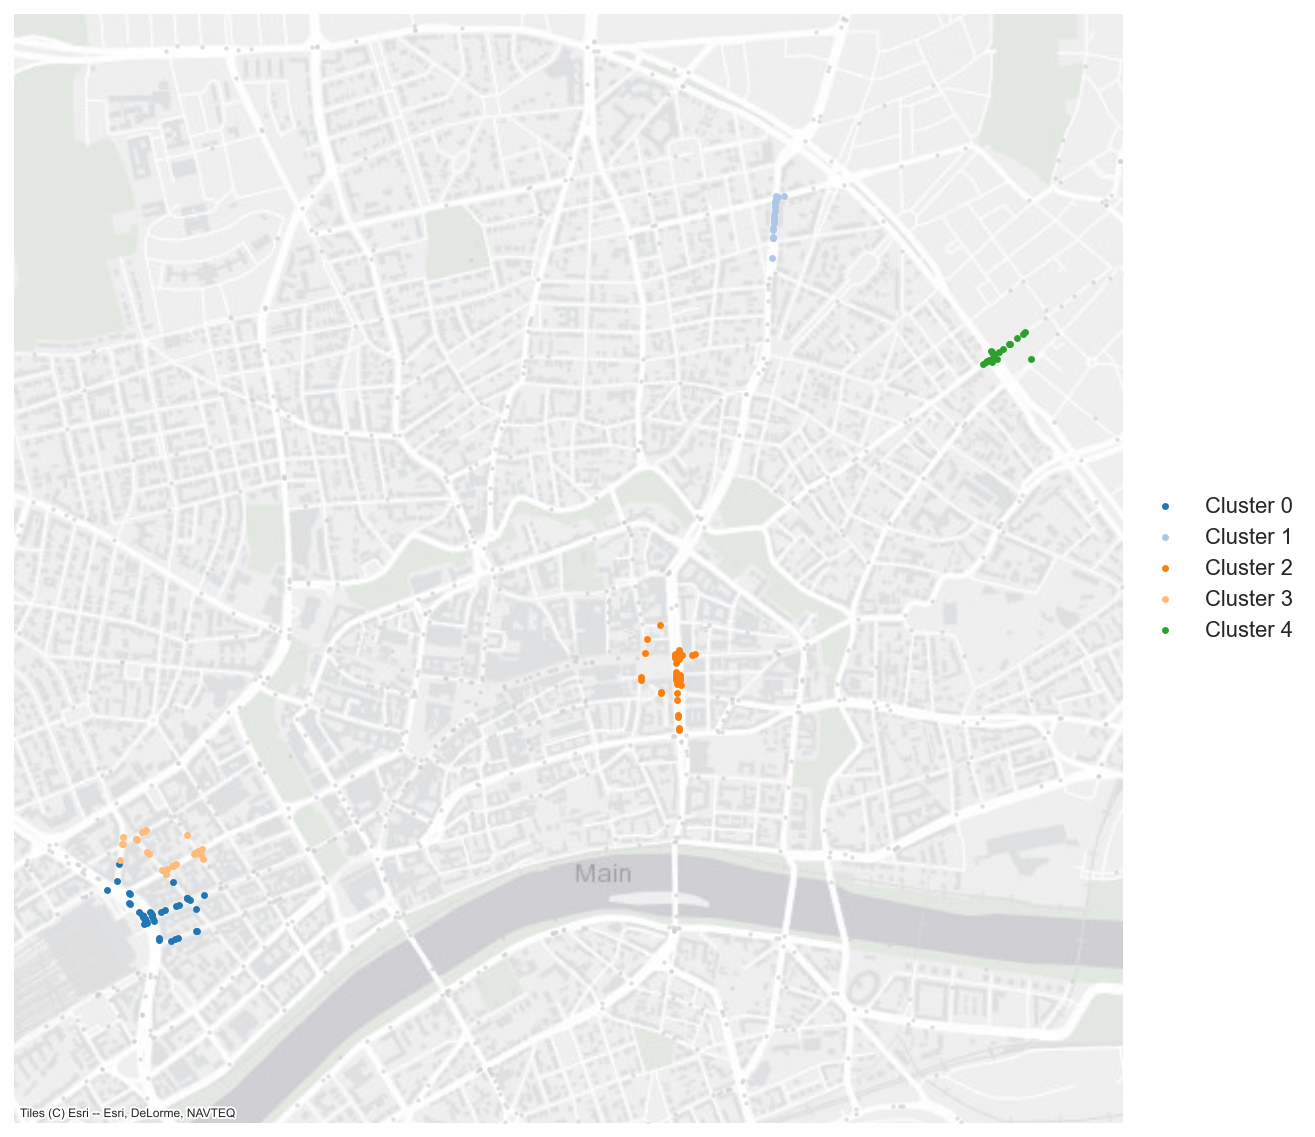

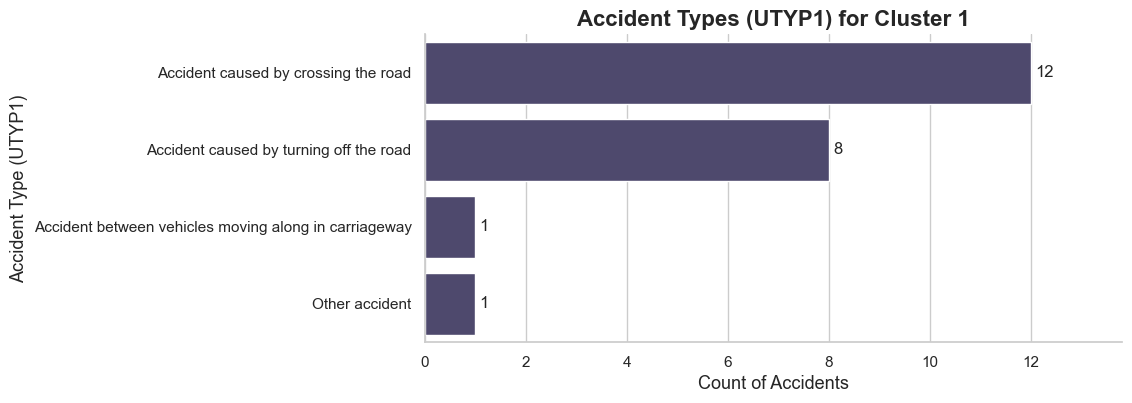

,OID_,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,...,IstKrad,IstGkfz,IstSonstige,LINREFX,LINREFY,XGCSWGS84,YGCSWGS84,Community_key,UID,labels
10593,10594,06,4,12,000,2016,2,13,3,1,...,0,1.0,0,478659.3040,5.552369e+06,8.701461,50.123180,06412000,2016_10594,4
13119,13120,06,4,12,000,2016,4,17,2,3,...,0,0.0,0,476050.0200,5.550641e+06,8.665068,50.107535,06412000,2016_13120,0
17145,17146,06,4,12,000,2016,7,5,6,3,...,0,0.0,0,475982.7214,5.550676e+06,8.664125,50.107848,06412000,2016_17146,0
20972,20973,06,4,12,000,2016,11,15,4,2,...,0,0.0,0,476021.7757,5.550638e+06,8.664673,50.107511,06412000,2016_20973,0
102583,102584,06,4,12,000,2016,1,10,4,2,...,0,0.0,0,478642.7542,5.552341e+06,8.701231,50.122922,06412000,2016_102584,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195550,195551,06,4,12,000,2024,11,1,1,3,...,0,0.0,1,477630.7496,5.551322e+06,8.687134,50.113726,06412000,2024_195551,2
195676,195677,06,4,12,000,2024,11,10,6,3,...,0,0.0,0,478716.6721,5.552395e+06,8.702262,50.123416,06412000,2024_195677,4
195825,195826,06,4,12,000,2024,10,21,4,3,...,0,0.0,0,477581.0086,5.551445e+06,8.686431,50.114830,06412000,2024_195826,2
196076,196077,06,4,12,000,2024,10,1,2,3,...,0,0.0,0,477678.2894,5.551371e+06,8.687796,50.114164,06412000,2024_196077,2


In [8]:
# Pedestrian Clusters
analyze_clusters(Frankfurt[Frankfurt["IstFuss"] == 1], eps=100, min_samples=20, cluster_to_plot=1)

We repeat the same process for Nighttime accidents.

Found 5 clusters.
Cluster Center Coordinates
         Latitude  Longitude  \
labels                         
0       50.118521   8.731182   
1       50.100288   8.667499   
2       50.109652   8.687842   
3       50.107302   8.656143   
4       50.114499   8.687865   

                                                                            Google_Maps_Link  
labels                                                                                        
0       https://www.google.com/maps/search/?api=1&query=50.118520922400045,8.731181789428613  
1       https://www.google.com/maps/search/?api=1&query=50.100287721500045,8.667498990875046  
2        https://www.google.com/maps/search/?api=1&query=50.10965207680005,8.687842489333375  
3        https://www.google.com/maps/search/?api=1&query=50.10730183256006,8.656142532560047  
4        https://www.google.com/maps/search/?api=1&query=50.11449913978383,8.687864541243284  


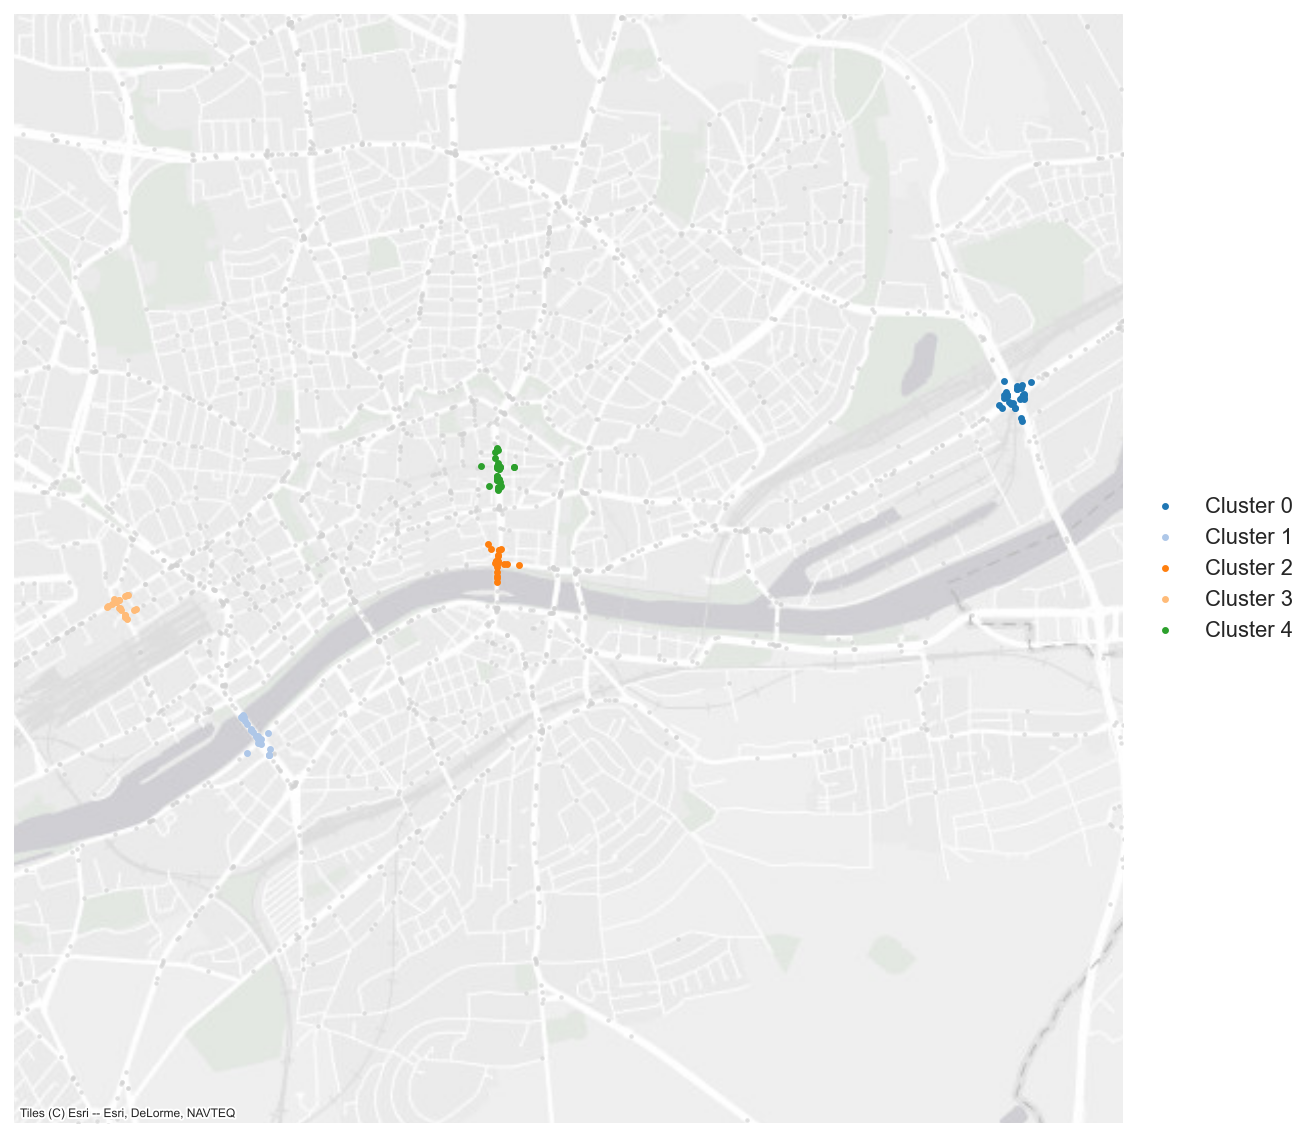

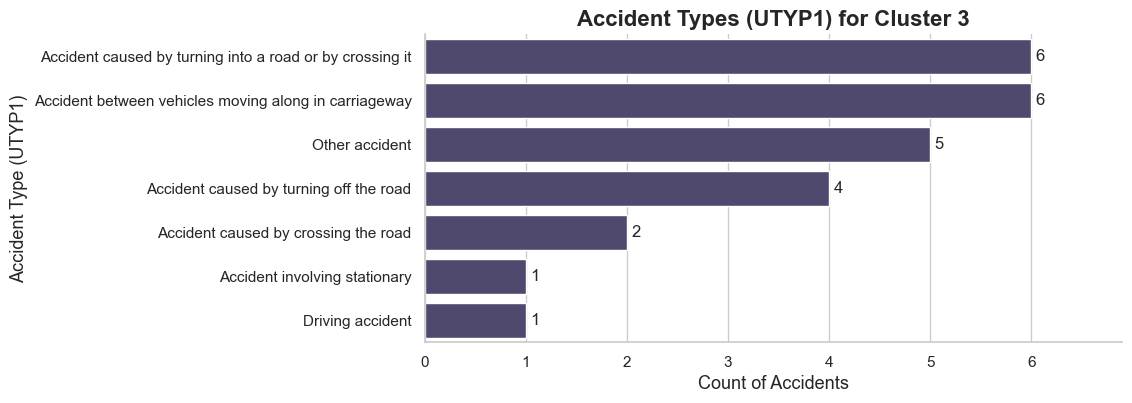

,OID_,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,...,IstKrad,IstGkfz,IstSonstige,LINREFX,LINREFY,XGCSWGS84,YGCSWGS84,Community_key,UID,labels
20419,20420,06,4,12,000,2016,11,20,4,3,...,0,0.0,0,480740.2491,5.551856e+06,8.730597,50.118637,06412000,2016_20420,0
21561,21562,06,4,12,000,2016,11,20,7,3,...,0,0.0,0,476193.5313,5.549872e+06,8.667123,50.100627,06412000,2016_21562,1
21946,21947,06,4,12,000,2016,12,18,2,3,...,0,0.0,0,480722.9345,5.551940e+06,8.730351,50.119394,06412000,2016_21947,0
22051,22052,06,4,12,000,2016,12,17,4,3,...,0,0.0,0,480838.3021,5.551858e+06,8.731969,50.118659,06412000,2016_22052,0
103867,103868,06,4,12,000,2016,4,20,3,3,...,0,0.0,0,477677.6340,5.550902e+06,8.687814,50.109951,06412000,2016_103868,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195608,195609,06,4,12,000,2024,11,17,4,3,...,0,0.0,0,480740.5438,5.551857e+06,8.730601,50.118640,06412000,2024_195609,0
195800,195801,06,4,12,000,2024,10,18,5,3,...,0,0.0,0,476293.6436,5.549853e+06,8.668524,50.100458,06412000,2024_195801,1
195825,195826,06,4,12,000,2024,10,21,4,3,...,0,0.0,0,477581.0086,5.551445e+06,8.686431,50.114830,06412000,2024_195826,4
196076,196077,06,4,12,000,2024,10,1,2,3,...,0,0.0,0,477678.2894,5.551371e+06,8.687796,50.114164,06412000,2024_196077,4


In [9]:
# Night time Clusters
analyze_clusters(Frankfurt[Frankfurt["ULICHTVERH"] == 2], eps=100, min_samples=25, cluster_to_plot=3)

And lastly, we are looking at serious injuries.

Found 5 clusters.
Cluster Center Coordinates
         Latitude  Longitude  \
labels                         
0       50.118604   8.731121   
1       50.107505   8.664689   
2       50.109202   8.694282   
3       50.106929   8.687506   
4       50.139080   8.670190   

                                                                            Google_Maps_Link  
labels                                                                                        
0       https://www.google.com/maps/search/?api=1&query=50.118603891400056,8.731121192840044  
1         https://www.google.com/maps/search/?api=1&query=50.10750546228577,8.66468914233338  
2       https://www.google.com/maps/search/?api=1&query=50.109202231312544,8.694282368562549  
3        https://www.google.com/maps/search/?api=1&query=50.10692851464291,8.687506379214325  
4        https://www.google.com/maps/search/?api=1&query=50.13908031600005,8.670189867071471  


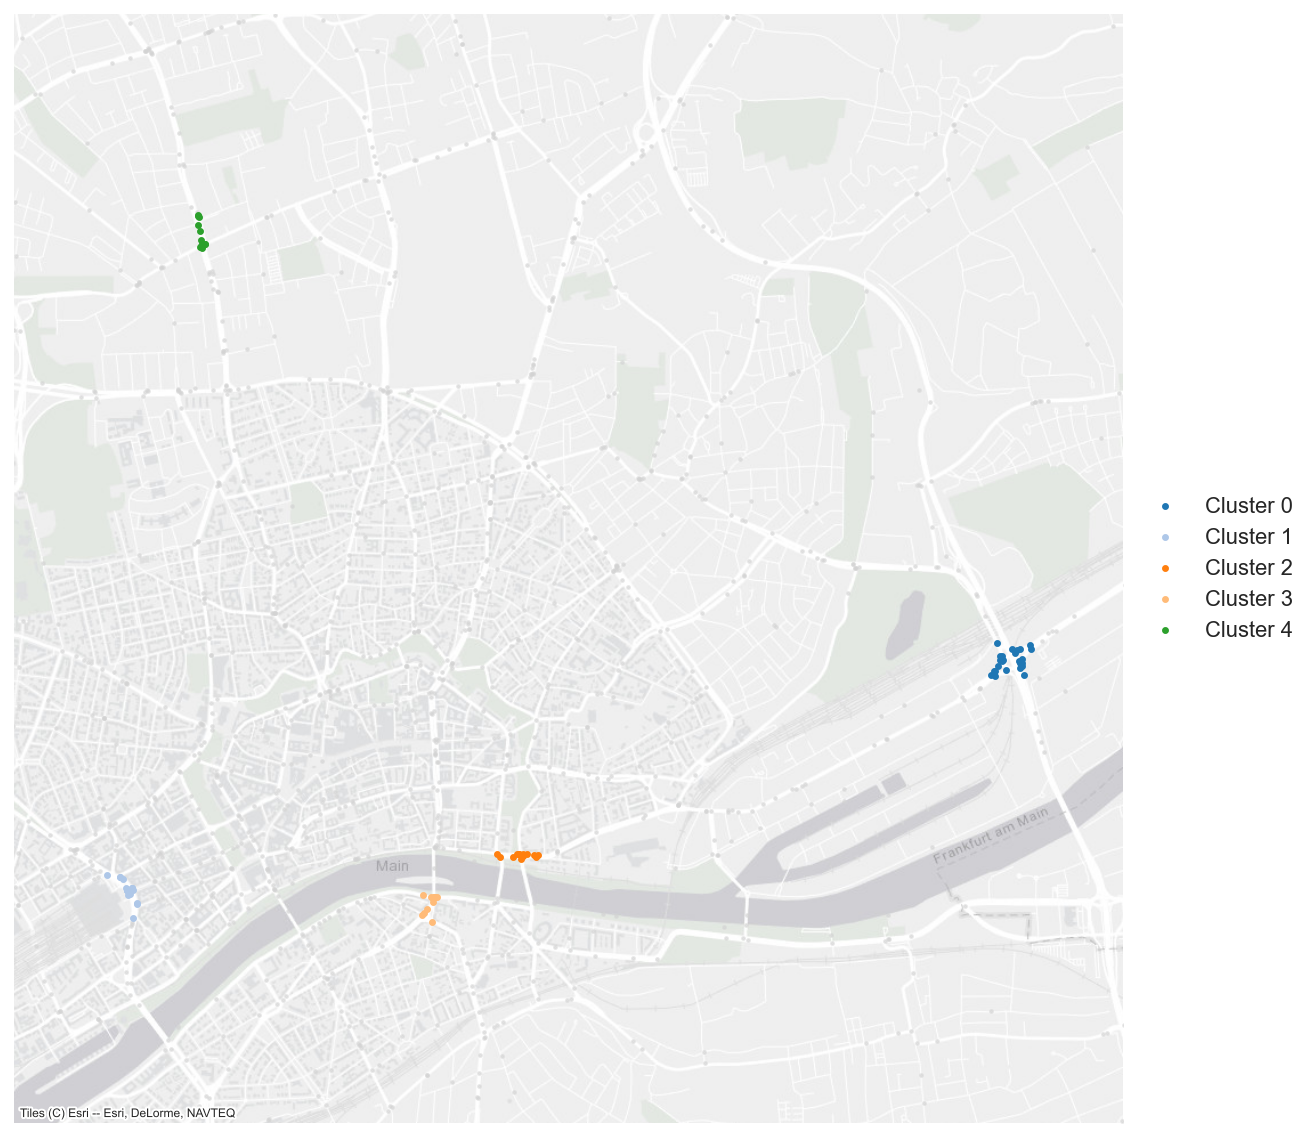

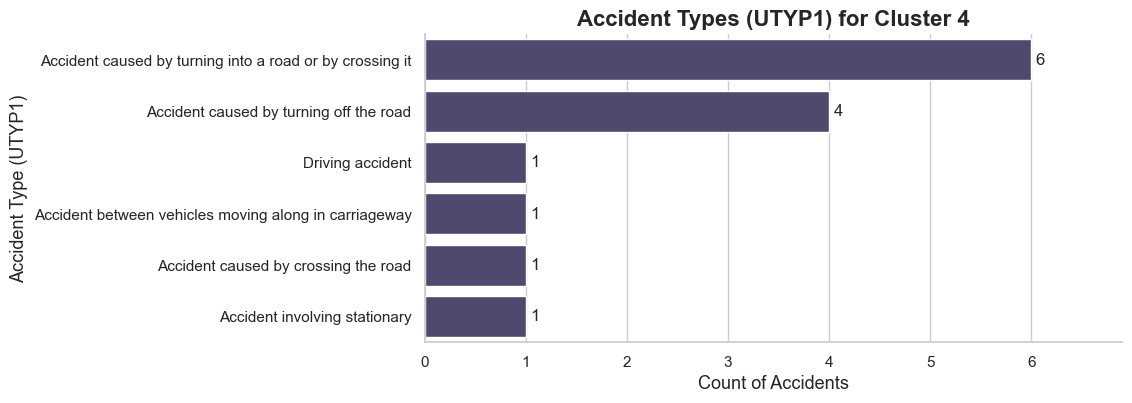

In [10]:
# Serious injury Clusters
clusters_df = analyze_clusters(Frankfurt[Frankfurt["UKATEGORIE"].isin([1, 2])], eps=100, min_samples=13, cluster_to_plot=4)

In [11]:
print("--- Accident Counts per UKATEGORIE (for each Cluster) ---")
category_counts = clusters_df.groupby('labels')['UKATEGORIE'].value_counts().sort_index()
print(category_counts)

--- Accident Counts per UKATEGORIE (for each Cluster) ---
labels  UKATEGORIE
0       2             25
1       2             21
2       1              1
        2             15
3       2             14
4       2             14
Name: count, dtype: int64
